In [5]:
print('Hello, World!')


Hello, World!


In [6]:
x=17


In [55]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
data = pd.read_csv(r'C:\Users\HP\Documents\DS project\DS_project\Fraudulent-prediction-project\data\nova_pay_combined.csv')


In [56]:
data['is_fraud'].value_counts()


is_fraud
0    10403
1      997
Name: count, dtype: int64

In [57]:
### There is a class imbalanace
import matplotlib.pyplot as plt


In [58]:
data.info()
data.shape


<class 'pandas.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  str    
 1   customer_id                11400 non-null  str    
 2   timestamp                  11371 non-null  str    
 3   home_country               11400 non-null  str    
 4   source_currency            11400 non-null  str    
 5   dest_currency              11400 non-null  str    
 6   channel                    11400 non-null  str    
 7   amount_src                 11400 non-null  str    
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  str    
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  str    
 14  i

(11400, 26)

In [59]:
null_column = data.isnull().mean() * 100 > 0
null_column[null_column == True]. index.tolist()


['timestamp',
 'amount_usd',
 'fee',
 'ip_address',
 'ip_country',
 'kyc_tier',
 'device_trust_score']

In [61]:
data.describe(include=['string', 'bool'])



,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,device_id,new_device,ip_address,ip_country,location_mismatch,kyc_tier
count,11400,11400,11371,11400,11400,11400,11400,11400,11400,11400,11095,11099,11400,11100
unique,11200,1315,11141,7,3,9,12,9856,2113,2,10900,9,2,14
top,4662cb2d-21b2-4390-ba38-5a1eddebdc7c,402cccc9-28de-45b3-9af7-cc5302aa1f93,0000-00-00T00:00:00Z,US,USD,NGN,mobile,100.0,e70db499-19e1-4927-b04f-3ebfcf62e33c,False,194.179.17.152,US,False,standard
freq,2,1510,21,7940,8031,1474,6366,15,87,10047,2,6848,9548,7931


### Task to do
- Dropping identifers
- deal with the duplicates 
- fix consistenties categorical values
- deal with the null values 

In [62]:
data.duplicated().sum()


np.int64(200)

In [63]:
##amount_src 
data['source_currency'].value_counts()


source_currency
USD    8031
GBP    2139
CAD    1230
Name: count, dtype: int64

In [64]:
## dealing with null values

data['amount_src'] = pd.to_numeric(data['amount_src'], errors='coerce')
data['amount_usd'] / data['amount_src']


0        1.000000
1        0.739965
2        1.000000
3        1.000000
4        1.000000
5        1.000000
6        0.740016
7        0.740009
8        1.000000
9        1.000000
10       1.000000
11       1.000000
12       1.000000
13            NaN
14       1.000000
15       1.000000
16       1.000000
17       1.000000
18       1.000000
19       1.000000
20       1.000000
21       0.739997
22       1.000000
23       1.000000
24       1.000000
25       1.000000
26       1.000000
27       0.739969
28       0.739993
29       1.000000
30       1.000000
31       1.000000
32       1.000000
33       1.000000
34       1.000000
35       0.740014
36       1.249991
37       1.000000
38       1.250027
39       1.249980
40       1.000000
41       0.739977
42       1.250054
43       1.000000
44       1.000000
45       1.000000
46       1.250051
47       1.000000
48       1.000000
49            NaN
50       1.249947
51       1.000000
52       1.000000
53       0.740000
54       0.739999
55       1

In [65]:
exchange_rate = data[data['amount_usd'].notna()].groupby('source_currency').apply(
    lambda x: (x['amount_usd'] / x['amount_src']).mean()
).to_dict()


In [66]:
data['amount_usd'] = data['amount_src'].fillna(
    data['amount_src'] * data['source_currency'].map(exchange_rate)
)


In [67]:
##data['timestamp'] = pd.to_datetime(data['timestamp'], errors= 'coerce')

data['amount_src'] = data['amount_src'].astype(str).str.strip()
data['amount_src'] = pd.to_numeric(data['amount_src'], errors='coerce')


In [68]:
##data[['timestamp', 'amount_src']].dtypes


In [69]:
data['fee'].dtype


dtype('float64')

In [70]:
for col in data.select_dtypes(include=['str', 'bool']).columns.tolist():
    print(data[col].value_counts())
    print('------------------------------')

    

transaction_id
4662cb2d-21b2-4390-ba38-5a1eddebdc7c    2
e69d481f-2ee3-4621-a58a-73fec8c63eca    2
8537371a-7eae-4108-89c9-5660e5025a88    2
2e553c23-063e-4b5e-aa2e-8a41d6aa61ca    2
a9198fb0-d831-48df-b434-c30a39078aa3    2
22566dff-8c67-4119-9d2d-fa23862199c8    2
a5c6391d-4763-4ed6-a5ef-80b744cf71b2    2
d111a38d-879a-4354-9666-82ce420b9f4a    2
4c80a822-dda8-46e0-a5f5-a621a24210b8    2
e952671a-33bc-4c98-9242-f47caad7741c    2
c0059f95-5daa-415b-b686-924d3ee4ca9b    2
88b5e91e-c9ba-4a58-b18f-a234a7a03cc8    2
883403f5-fd2f-4b39-824e-9710485a983e    2
a71aaac9-2819-4f46-9ec9-1f2699ecc2aa    2
35c133e7-7279-4d24-ac0e-967675f2c2a0    2
40049bb9-944d-4add-8f1f-06c2732e8a9d    2
f70c112d-9406-4ac9-b1fd-d31f4d972e0e    2
1174a4a4-d11e-423f-b212-c70a2986df4e    2
a96e7cc8-8d34-464d-8d93-b0dab38db30b    2
41ffc5f6-a17e-4a3e-97be-be4cf7f38860    2
6fb7ec3b-f110-403c-a2d1-45bbdc8a3a21    2
c6a33674-6b37-486d-b5e1-59d4ce216d69    2
15147f81-9cf6-41dc-8853-b93d16544df6    2
fb3ab3bb-7f13-4a07-

In [71]:
typo_corrections = {
    'channel': {'mobille': 'mobile', 'weeb': 'web'},
    'kyc_tier': {'standrd': 'standard', 'enhancd': 'enhanced', 'enchncd': 'enhanced', 'nan': 'unknown'},
    'ip_country': {'nan': 'unknown'},
}

# Apply corrections where columns exist
for col, mapping in typo_corrections.items():
    if col in data.columns:
        data[col] = data[col].replace(mapping)


In [72]:
##data.duplicates(subset=['transaction_id'], inplace=True)
##data=data.drop_duplicates()



In [74]:
data.shape



(11400, 26)

In [75]:
data=data.drop(columns=['device_id'])


In [76]:
##data=data.drop(columns=['ip_address', 'timestamp'])


In [77]:
data.duplicated().sum()


np.int64(200)

In [79]:
data.shape


(11400, 25)

In [80]:

## fix text consistency

import numpy as np



In [81]:
data['kyc_tier'] = data['kyc_tier'].str.strip().str.lower()


In [82]:

## Fix text consistency

data['kyc_tier'] = data['kyc_tier'].replace({
    'standrd': 'standard',
    'enhancd': 'enhanced',
    'enchncd': 'enhanced'
})


In [83]:


data['ip_country'] = data['ip_country'].str.strip().str.lower()


In [84]:
## Deal with inconsistent categorical variables

for col in data.select_dtypes(include=['object']).columns.tolist():
    data[col] =data[col].str.strip().str.lower()

    

C:\Users\HP\AppData\Local\Temp\ipykernel_7136\3718273006.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(include=['object']).columns.tolist():


In [85]:
###Filling in missing gap in amount_src with median value

import matplotlib.pyplot as plt


In [86]:
if 'kyc_tier' in data.columns:
    mode_kyc = data['kyc_tier'].mode().iloc[0] if not data['kyc_tier'].mode().empty else 'unknown'
    data['kyc_tier'] = data['kyc_tier'].fillna(mode_kyc)


In [87]:
##ip_country missing values

if {'ip_country', 'home_country'}.issubset(data.columns):
    data['ip_country'] = data['ip_country'].fillna(data['home_country'])

    

In [88]:
##filling fee missing values with median

if 'fee' in data.columns:
    if 'channel' in data.columns:
        data['fee'] = data.groupby('channel')['fee'].transform(lambda x: x.fillna(x.median()))
    data['fee'] = data['fee'].fillna(data['fee'].median())


In [89]:
if 'device_trust_score' in data.columns:
    if 'kyc_tier' in data.columns:
        data['device_trust_score'] = data.groupby(
            'kyc_tier'
        )['device_trust_score'].transform(
            lambda x: x.fillna(x.median())
        )
    data['device_trust_score'] = data['device_trust_score'].fillna(
        data['device_trust_score'].median()
    )


In [90]:
data.isnull().sum()


transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     4
amount_usd                     4
fee                            0
exchange_rate_src_to_dest      0
new_device                     0
ip_address                   305
ip_country                     0
location_mismatch              0
ip_risk_score                  0
kyc_tier                       0
account_age_days               0
device_trust_score             0
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [40]:
##data = data.drop(columns=['timestamp', 'ip_address'])


EDA PROCESS

In [91]:
data.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)


is_fraud                     1.000000
txn_velocity_24h             0.750092
txn_velocity_1h              0.686235
risk_score_internal          0.601174
chargeback_history_count     0.580136
ip_risk_score                0.518930
location_mismatch            0.416710
new_device                   0.376999
corridor_risk                0.192821
exchange_rate_src_to_dest    0.152035
amount_src                   0.128863
amount_usd                   0.128863
fee                         -0.013618
account_age_days            -0.284191
device_trust_score          -0.386301
Name: is_fraud, dtype: float64

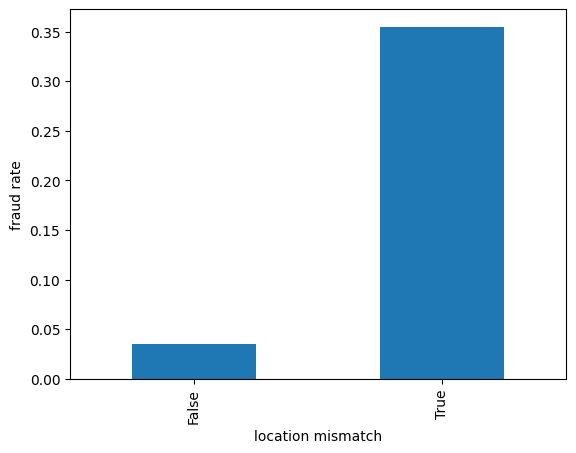

In [92]:
import matplotlib.pyplot as plt

## Visualize the relationship between location_mismatch and is_fraud
data.groupby("location_mismatch")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("location mismatch")
plt.show()


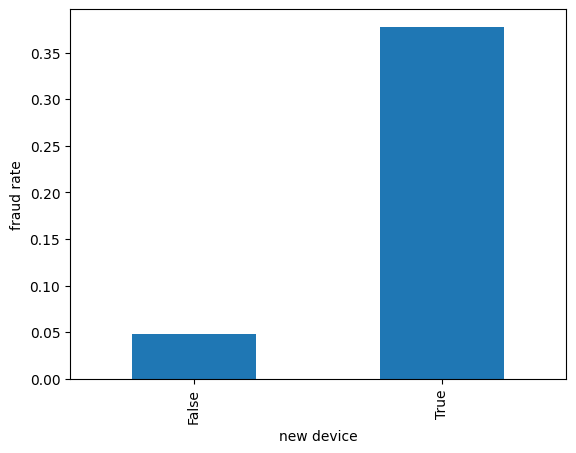

In [93]:
## Visualize the relationship between new_device and is_fraud

data.groupby("new_device")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("new device")
plt.show()


In [94]:
categorical_cols = data.select_dtypes(include=['object', 'category']).columns
categorical_cols


C:\Users\HP\AppData\Local\Temp\ipykernel_7136\1518346218.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include=['object', 'category']).columns


Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'ip_address',
       'ip_country', 'kyc_tier'],
      dtype='str')

In [95]:
##data['kyc_tier'] = data['kyc_tier'].str.strip().str.lower()


CHANNEL before: <StringArray>
['atm', 'web', 'mobile', 'unknown']
Length: 4, dtype: str
KYC before: <StringArray>
['standard', 'enhanced', 'low', 'nan', 'unknown']
Length: 5, dtype: str
CHANNEL after: <StringArray>
['atm', 'web', 'mobile', 'unknown']
Length: 4, dtype: str
KYC after: <StringArray>
['standard', 'enhanced', 'low', 'nan', 'unknown']
Length: 5, dtype: str


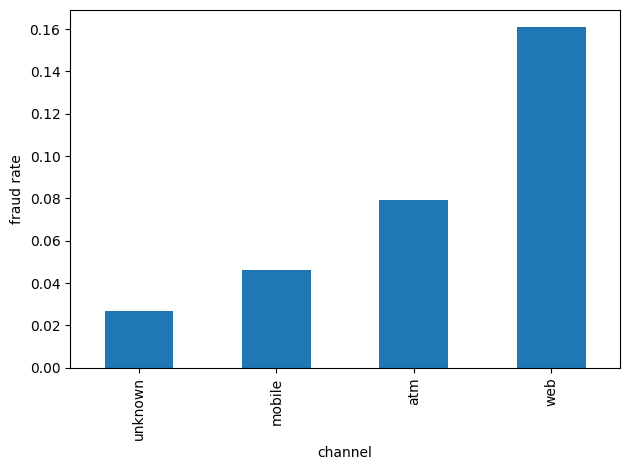

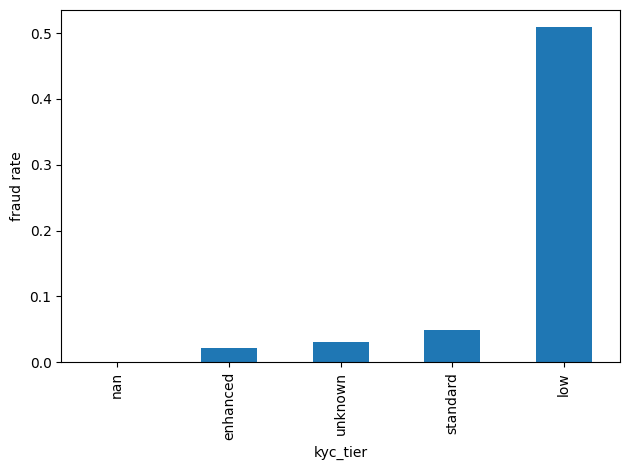

In [96]:
# Inspect current values
print('CHANNEL before:', pd.Series(data['channel']).unique())
print('KYC before:', pd.Series(data['kyc_tier']).unique())

# Normalize and replace (do this AFTER any earlier cleaning cells)
for col in ['channel','kyc_tier']:
    if col in data.columns:
        data[col] = data[col].astype(str).str.strip().str.lower()

data['channel'] = data['channel'].replace({'mobille':'mobile','weeb':'web'})
data['kyc_tier'] = data['kyc_tier'].replace({
    'standrd':'standard','enhancd':'enhanced','enchncd':'enhanced'
})

# Verify
print('CHANNEL after:', pd.Series(data['channel']).unique())
print('KYC after:', pd.Series(data['kyc_tier']).unique())

# Replot the two graphs
import matplotlib.pyplot as plt
data.groupby('channel')['is_fraud'].mean().sort_values().plot(kind='bar')
plt.xlabel('channel'); plt.ylabel('fraud rate'); plt.tight_layout(); plt.show()

data.groupby('kyc_tier')['is_fraud'].mean().sort_values().plot(kind='bar')
plt.xlabel('kyc_tier'); plt.ylabel('fraud rate'); plt.tight_layout(); plt.show()


In [97]:
data.isnull().sum()


transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     4
amount_usd                     4
fee                            0
exchange_rate_src_to_dest      0
new_device                     0
ip_address                   305
ip_country                     0
location_mismatch              0
ip_risk_score                  0
kyc_tier                       0
account_age_days               0
device_trust_score             0
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [98]:
# Extract time-based features

data = data.dropna(subset=['timestamp'])
print(f"Shape after dropping null timestamps: {data.shape}")

data['timestamp'] = pd.to_datetime(data['timestamp'], errors='coerce')


data['hour'] = data['timestamp'].dt.hour

data['day_of_week'] = data['timestamp'].dt.dayofweek  # 0=Monday, 6=Sunday
data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)

print("Time features created:")
print(data[['timestamp', 'hour', 'day_of_week', 'is_weekend']].head())

print("\nHour distribution:")
print(data['hour'].value_counts().sort_index())


Shape after dropping null timestamps: (11371, 25)
Time features created:
                         timestamp  hour  day_of_week  is_weekend
0 2022-10-03 18:40:59.468549+00:00  18.0          0.0           0
1 2022-10-03 20:39:38.468549+00:00  20.0          0.0           0
2 2022-10-03 23:02:43.468549+00:00  23.0          0.0           0
3 2022-10-04 01:08:53.468549+00:00   1.0          1.0           0
4 2022-10-04 09:35:03.468549+00:00   9.0          1.0           0

Hour distribution:
hour
0.0     472
1.0     419
2.0     432
3.0     504
4.0     520
5.0     494
6.0     486
7.0     464
8.0     501
9.0     445
10.0    474
11.0    452
12.0    467
13.0    471
14.0    442
15.0    485
16.0    476
17.0    447
18.0    485
19.0    520
20.0    465
21.0    444
22.0    470
23.0    504
Name: count, dtype: int64


In [99]:
## Drop rows with null timestamp
data = data.dropna(subset=['timestamp'])
print(f"Shape after dropping null timestamps: {data.shape}")


Shape after dropping null timestamps: (11339, 28)


hour
0.0     0.061441
1.0     0.062053
2.0     0.076389
3.0     0.121032
4.0     0.180769
5.0     0.155870
6.0     0.203704
7.0     0.176724
8.0     0.123752
9.0     0.044944
10.0    0.069620
11.0    0.075221
12.0    0.059957
13.0    0.063694
14.0    0.076923
15.0    0.057732
16.0    0.063025
17.0    0.053691
18.0    0.076289
19.0    0.044231
20.0    0.060215
21.0    0.076577
22.0    0.057447
23.0    0.043651
Name: is_fraud, dtype: float64


Text(0, 0.5, 'Fraud Rate')

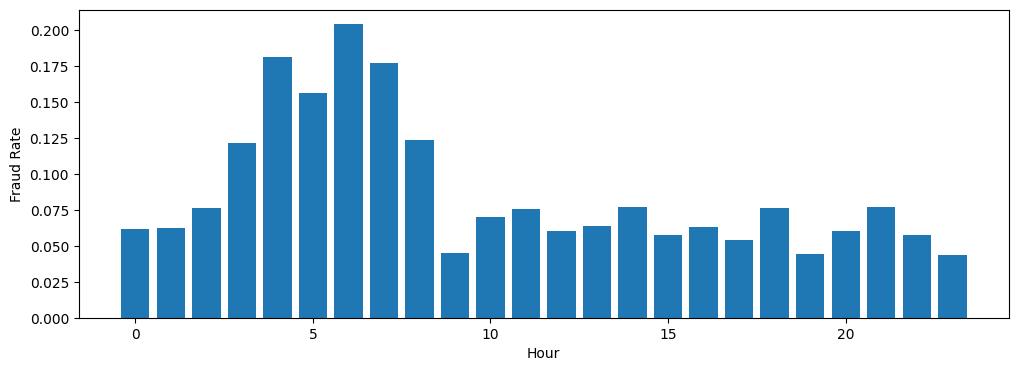

In [100]:
#Fraud rate by hour
fraud_by_hour = data.groupby('hour')['is_fraud'].mean()

print(fraud_by_hour)

plt.figure(figsize=(12, 4))
plt.bar(fraud_by_hour.index, fraud_by_hour.values)
plt.xlabel('Hour')
plt.ylabel('Fraud Rate')


In [101]:
data.dropna(inplace=True)


In [102]:
data.isnull().sum()


transaction_id               0
customer_id                  0
timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
new_device                   0
ip_address                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
hour                         0
day_of_week                  0
is_weekend                   0
dtype: int64

In [ ]:
#save data
data.to_csv(r'C:\Users\HP\Documents\DS project\DS_project\Fraudulent-prediction-project\data\cleaned_fraud_data.csv', index=False)
